# Лабораторная работа 4. Цифровая фильтрация изображений

**Вариант 9**

В работе исследуются пространственные фильтры сглаживания и выделения границ, повышение резкости, а также гауссов высокочастотный фильтр в частотной области. Используется изображение `../lab2/image.png` из лабораторной работы 2.

## Теоретическая справка

При пространственной фильтрации новое значение пикселя вычисляется по его окрестности с помощью ядра свёртки. Линейные фильтры усредняют или взвешивают значения соседних пикселей, а нелинейный медианный фильтр выбирает медиану. Увеличение окна усиливает сглаживание, но может размывать детали.

Операторы Собеля оценивают первую производную по горизонтали и вертикали и выделяют границы. Повышение резкости усиливает высокочастотные детали. В частотной области изображение преобразуется БПФ, спектр умножается на маску фильтра, затем выполняется обратное преобразование. Гауссов ВЧ-фильтр подавляет низкие частоты и оставляет плавные контуры без резкой границы идеальной маски.

Размер: 1000 x 563; диапазон: 0 ... 255


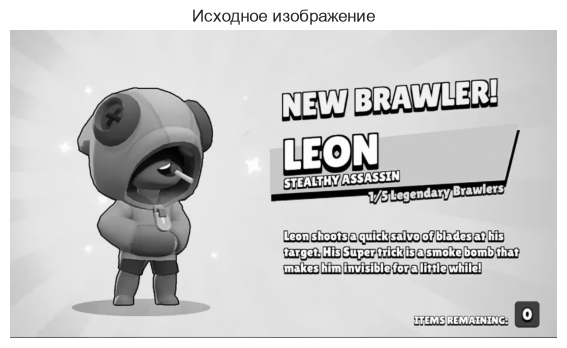

In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
IMAGE_PATH = Path('../lab2/image.png')
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f'Не найден файл {IMAGE_PATH.resolve()}')

image = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_GRAYSCALE)
if image is None:
    raise ValueError('OpenCV не смогла прочитать изображение')

height, width = image.shape
print(f'Размер: {width} x {height}; диапазон: {image.min()} ... {image.max()}')
plt.figure(figsize=(8, 4))
plt.imshow(image, cmap='gray', vmin=0, vmax=255)
plt.title('Исходное изображение')
plt.axis('off')
plt.show()

## 1. Усредняющие фильтры 5×5 и 11×11

Среднее абсолютное изменение для 5×5: 7.65
Среднее абсолютное изменение для 11×11: 13.60


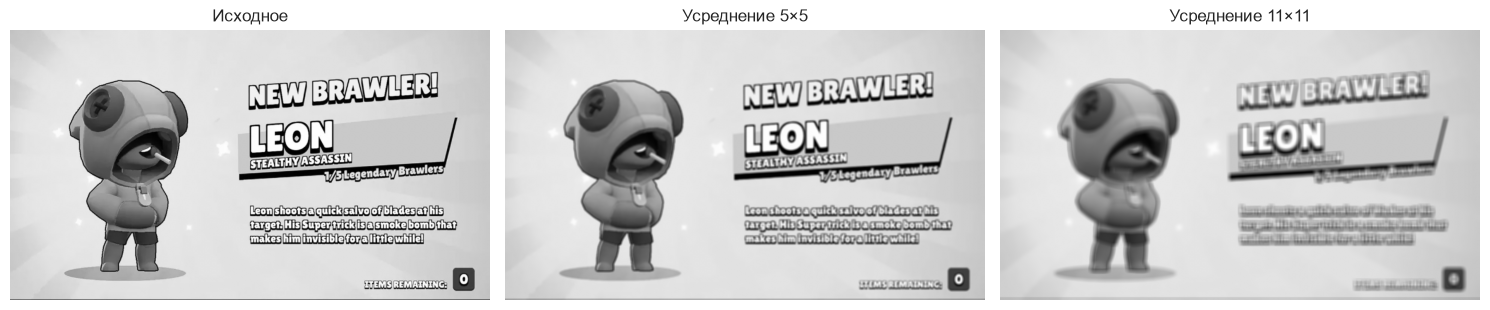

In [2]:
blur_5 = cv2.blur(image, (5, 5))
blur_11 = cv2.blur(image, (11, 11))
mean_abs_diff_5 = np.mean(np.abs(image.astype(np.float32) - blur_5))
mean_abs_diff_11 = np.mean(np.abs(image.astype(np.float32) - blur_11))
print(f'Среднее абсолютное изменение для 5×5: {mean_abs_diff_5:.2f}')
print(f'Среднее абсолютное изменение для 11×11: {mean_abs_diff_11:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for axis, data, title in zip(axes, [image, blur_5, blur_11], ['Исходное', 'Усреднение 5×5', 'Усреднение 11×11']):
    axis.imshow(data, cmap='gray', vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis('off')
plt.tight_layout()
plt.show()

## 2. Медианный фильтр против шума «соль и перец

Средняя ошибка относительно исходного: шум 6.34, после медианного фильтра 4.44


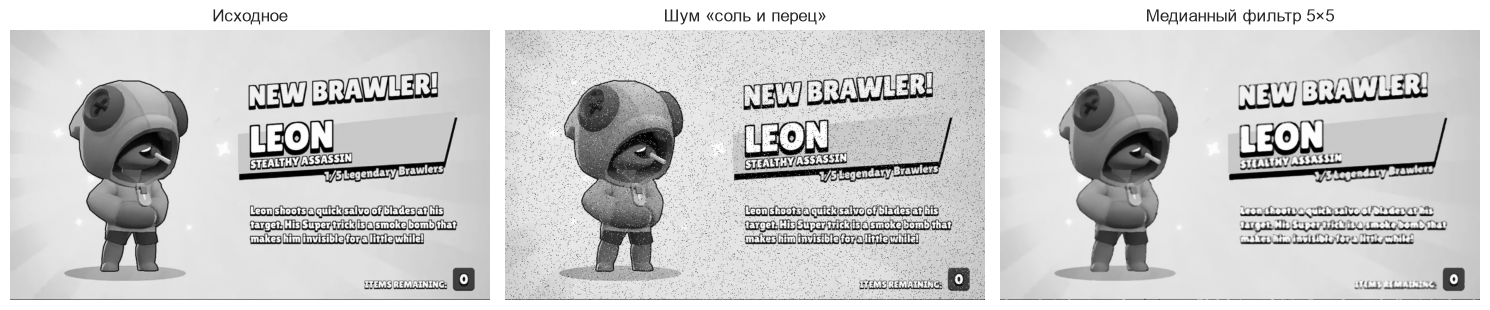

In [3]:
rng = np.random.default_rng(42)
noisy = image.copy()
noise_mask = rng.random(image.shape)
noisy[noise_mask < 0.025] = 0
noisy[noise_mask > 0.975] = 255
median_5 = cv2.medianBlur(noisy, 5)
noise_mae = np.mean(np.abs(image.astype(np.float32) - noisy))
median_mae = np.mean(np.abs(image.astype(np.float32) - median_5))
print(f'Средняя ошибка относительно исходного: шум {noise_mae:.2f}, после медианного фильтра {median_mae:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for axis, data, title in zip(axes, [image, noisy, median_5], ['Исходное', 'Шум «соль и перец»', 'Медианный фильтр 5×5']):
    axis.imshow(data, cmap='gray', vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis('off')
plt.tight_layout()
plt.show()

## 3. Выделение границ оператором Собеля

Максимум Собеля X: 1016
Максимум Собеля Y: 1016


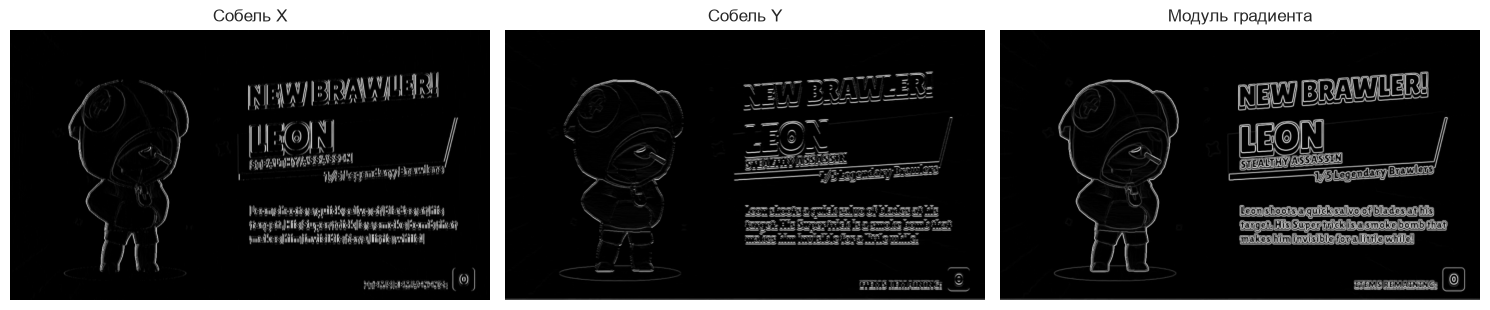

In [4]:
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
sobel_magnitude = cv2.magnitude(sobel_x.astype(np.float32), sobel_y.astype(np.float32))
sobel_magnitude = cv2.normalize(sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
print(f'Максимум Собеля X: {np.max(np.abs(sobel_x)):.0f}')
print(f'Максимум Собеля Y: {np.max(np.abs(sobel_y)):.0f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for axis, data, title in zip(axes, [np.abs(sobel_x), np.abs(sobel_y), sobel_magnitude], ['Собель X', 'Собель Y', 'Модуль градиента']):
    axis.imshow(data, cmap='gray')
    axis.set_title(title)
    axis.axis('off')
plt.tight_layout()
plt.show()

## 4. Фильтр повышения резкости

Среднее абсолютное изменение после sharpen: 5.62


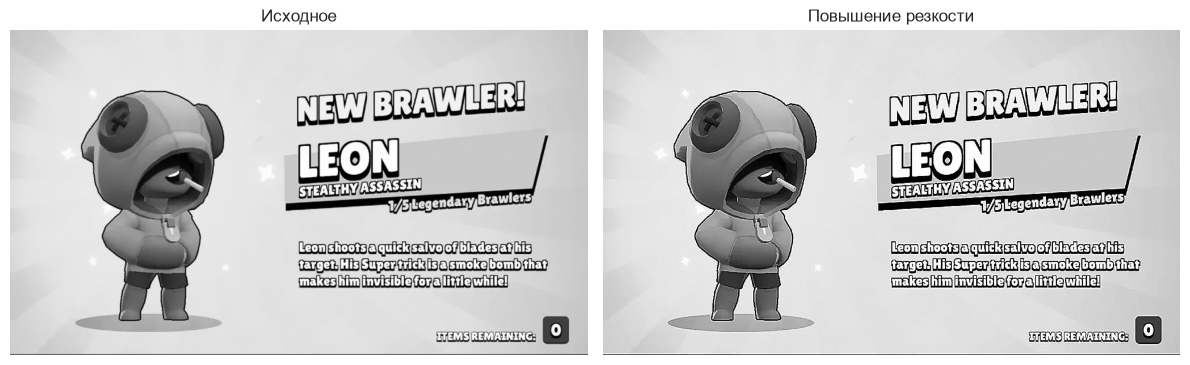

In [5]:
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
sharpened = cv2.filter2D(image, -1, sharpen_kernel)
print(f'Среднее абсолютное изменение после sharpen: {np.mean(np.abs(image.astype(np.float32) - sharpened)):.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Исходное')
axes[1].imshow(sharpened, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Повышение резкости')
for axis in axes:
    axis.axis('off')
plt.tight_layout()
plt.show()

## 5. Гауссов высокочастотный фильтр в частотной области

Радиус настройки фильтра (sigma): 45.0


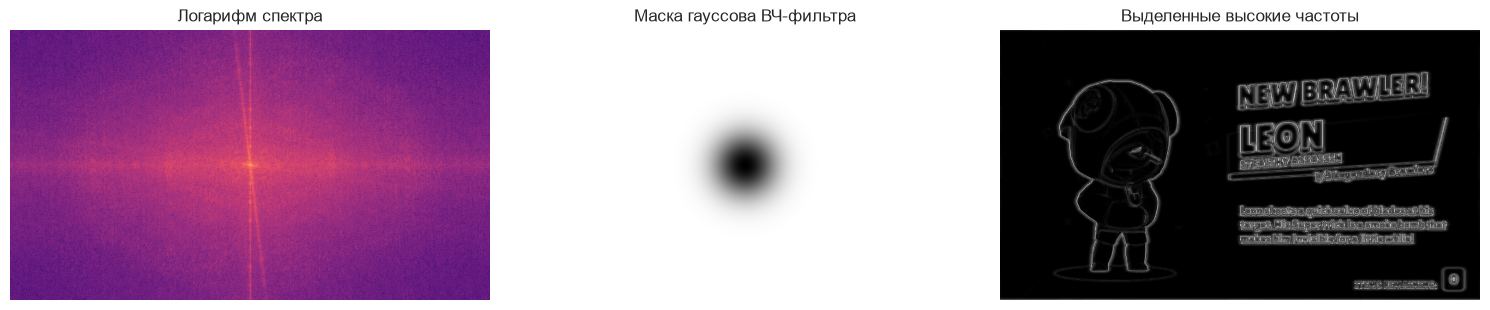

In [6]:
spectrum = np.fft.fftshift(np.fft.fft2(image))
rows, cols = image.shape
y, x = np.ogrid[:rows, :cols]
distance_sq = (x - cols // 2) ** 2 + (y - rows // 2) ** 2
sigma = 45.0
gaussian_lpf = np.exp(-distance_sq / (2 * sigma ** 2))
gaussian_hpf = 1.0 - gaussian_lpf
filtered_spectrum = spectrum * gaussian_hpf
high_pass_response = np.fft.ifft2(np.fft.ifftshift(filtered_spectrum))
high_pass_response = np.abs(high_pass_response)
high_pass_display = cv2.normalize(high_pass_response, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
print(f'Радиус настройки фильтра (sigma): {sigma}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(np.log1p(np.abs(spectrum)), cmap='magma')
axes[0].set_title('Логарифм спектра')
axes[1].imshow(gaussian_hpf, cmap='gray')
axes[1].set_title('Маска гауссова ВЧ-фильтра')
axes[2].imshow(high_pass_display, cmap='gray')
axes[2].set_title('Выделенные высокие частоты')
for axis in axes:
    axis.axis('off')
plt.tight_layout()
plt.show()

## Вывод

Окно усредняющего фильтра `11×11` сглаживает сильнее, чем `5×5`, но заметнее размывает детали. Медианный фильтр эффективно удаляет импульсный шум, сохраняя контуры лучше линейного усреднения. Собель выделяет границы через первую производную, sharpen усиливает локальные переходы яркости, а гауссов ВЧ-фильтр в частотной области подавляет медленно меняющийся фон и оставляет детали и контуры.

## Контрольные вопросы

1. Что такое фильтрация изображений и для чего она используется?
2. Чем отличается линейная фильтрация от нелинейной?
3. Какие виды шумов бывают на изображениях?
4. Как размер окна фильтра влияет на результат?
5. Когда предпочтительна пространственная, а когда частотная фильтрация?
6. В чём принцип работы усредняющего фильтра?
7. Чем гауссов фильтр отличается от простого усреднения?
8. Для какого шума эффективен медианный фильтр?
9. Что делают операторы Собеля и Превитта?
10. Чем Лаплас отличается от Собеля?
11. Как реализуется sharpen или unsharp masking?
12. Как интерпретировать низкие и высокие частоты?
13. Как выполняется переход в частотную область?
14. Какие шаги выполняются при частотной фильтрации?
15. Чем идеальный НЧ-фильтр отличается от гауссова?
16. Какие артефакты даёт идеальный НЧ-фильтр?
17. Как работает ВЧ-фильтр?
18. Что такое полосовой фильтр?
19. Какие преимущества даёт частотная фильтрация?
20. Почему БПФ эффективно при больших ядрах?